<a href="https://colab.research.google.com/github/Pawankumarkoiri/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Disease Prediction


### Project Overview
This project predicts whether a person is likely to have heart disease based on various medical attributes using the Logistic Regression algorithm.

### Objectives
- Understand the dataset
- Perform Exploratory Data Analysis (EDA)
- Visualize important patterns
- Train a Logistic Regression model
- Evaluate model performance
- Predict heart disease for new patient data

### Tools & Technologies
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
```



In [1]:
# ==============================
# Import Required Libraries
# ==============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Improve graph appearance
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


Data Collection And Processing


In [3]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('/content/heart.csv')

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [4]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
# Numbers of rows and columns
print("Shape of Dataset:", heart_data.shape )

Shape of Dataset: (1025, 14)


In [6]:
# Dataset Information
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
# Missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
#Statistical Summary
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# Column Names
heart_data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [10]:
# Count of Heart Disease and No Heart Disease
heart_data['target'].value_counts()

,count
target,
1,526
0,499


1 --> Defective Heart
0 --> Healthy Heart

In [11]:
# Percentage Distribution
heart_data['target'].value_counts(normalize=True) * 100

,proportion
target,
1,51.317073
0,48.682927


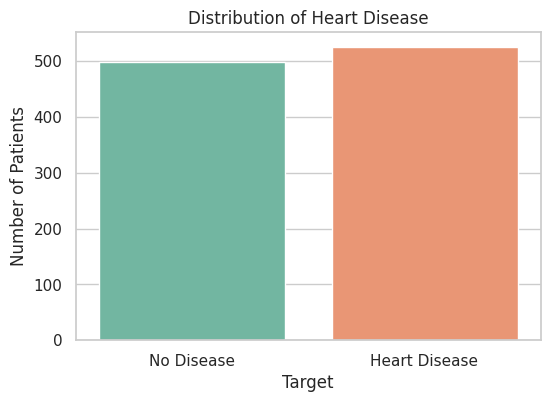

In [12]:
# Heart Disease Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=heart_data,
    palette='Set2'
)

plt.title("Distribution of Heart Disease")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0,1],["No Disease","Heart Disease"])

plt.show()

This graph show the numbers of patients with and without heart disease.

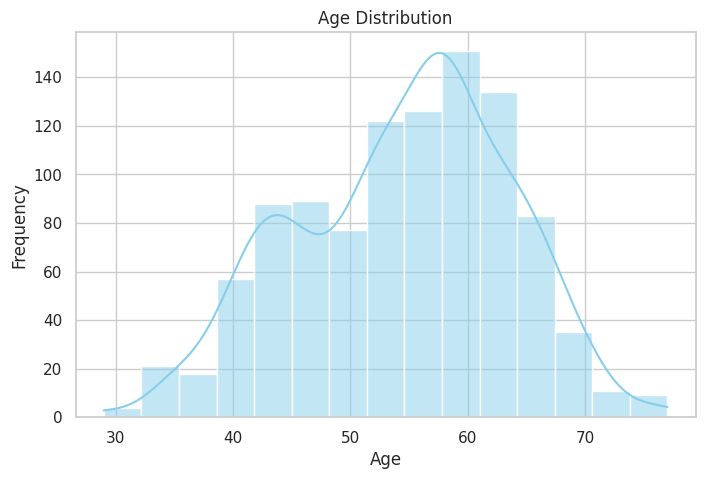

In [13]:
# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    heart_data['age'],
    bins=15,
    kde=True,
    color='skyblue'
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

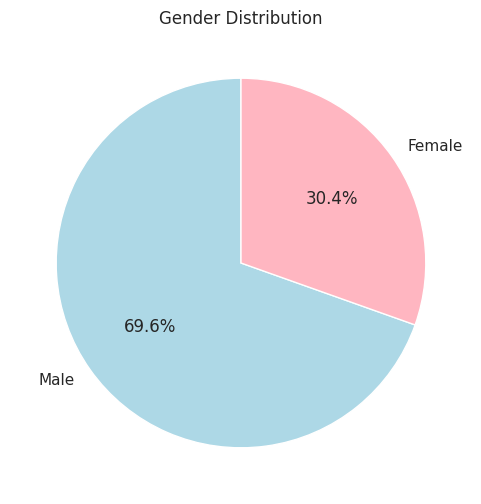

In [14]:
# Gender Distribution
gender = heart_data['sex'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=["Male","Female"],
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue','lightpink']
)

plt.title("Gender Distribution")
plt.show()

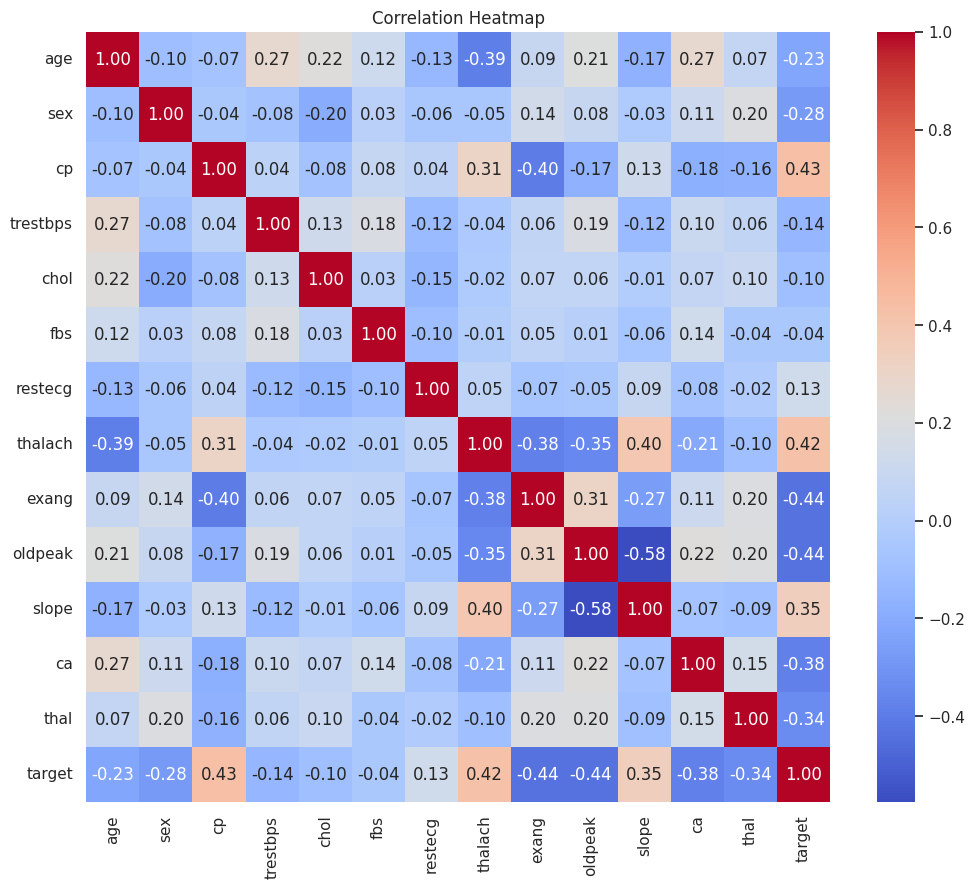

In [16]:
# Correlation Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    heart_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


In [19]:
# Separate Features And Target

# Features (Independent Variables)
X = heart_data.drop(columns='target', axis=1)

# Target (Dependent Variable)
y = heart_data['target']

X.head()
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [20]:
# Check Feature Shape
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1025, 13)
Shape of y: (1025,)


Splitting the Data into Training data & test data

In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (820, 13)
Testing Data: (205, 13)


Train The Logistic Regression Model

In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")

✅ Model Trained Successfully!


In [25]:
# Make Predictions
train_prediction = model.predict(X_train)

test_prediction = model.predict(X_test)

In [26]:
# Calculate Accuracy
train_accuracy = accuracy_score(y_train, train_prediction)

print("Training Accuracy:", round(train_accuracy * 100, 2), "%")

test_accuracy = accuracy_score(y_test, test_prediction)

print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")

Training Accuracy: 84.88 %
Testing Accuracy: 81.46 %


Visualization: Compare Train VS Test Accuracy

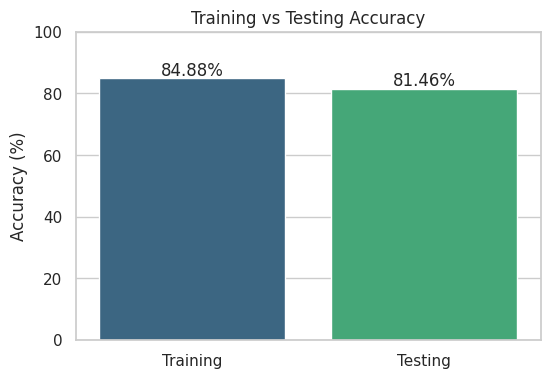

In [27]:
accuracy_scores = [
    train_accuracy * 100,
    test_accuracy * 100
]

labels = ["Training", "Testing"]

plt.figure(figsize=(6,4))

sns.barplot(x=labels, y=accuracy_scores, palette="viridis")

plt.ylim(0, 100)

plt.ylabel("Accuracy (%)")
plt.title("Training vs Testing Accuracy")

for i, score in enumerate(accuracy_scores):
    plt.text(i, score + 1, f"{score:.2f}%", ha='center')

plt.show()

Confusion Matrix

In [28]:
cm = confusion_matrix(y_test, test_prediction)

print(cm)

[[70 30]
 [ 8 97]]


Confusion Matrix Heatmap

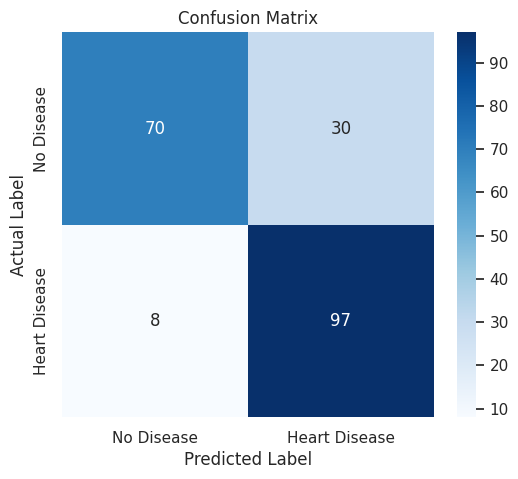

In [29]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Heart Disease'],
    yticklabels=['No Disease', 'Heart Disease']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

Classification Report

In [31]:
print(classification_report(y_test, test_prediction))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.76      0.92      0.84       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205



ROC Curve

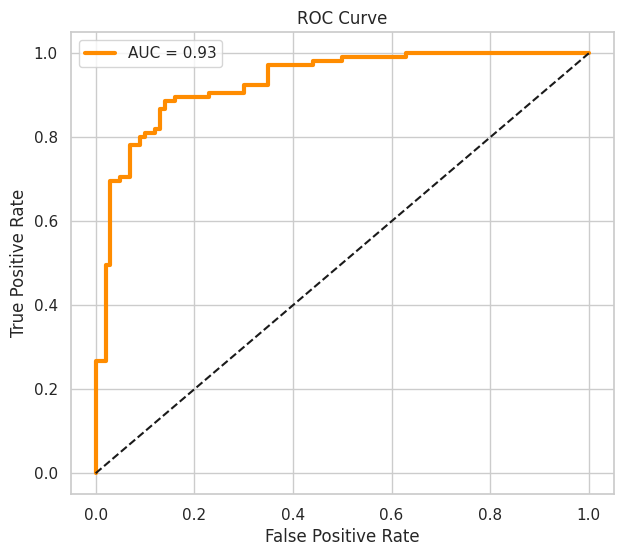

In [33]:
# Probability Predictions
y_prob = model.predict_proba(X_test)[:,1]

# ROC Values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         color='darkorange',
         linewidth=3,
         label=f"AUC = {auc_score:.2f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

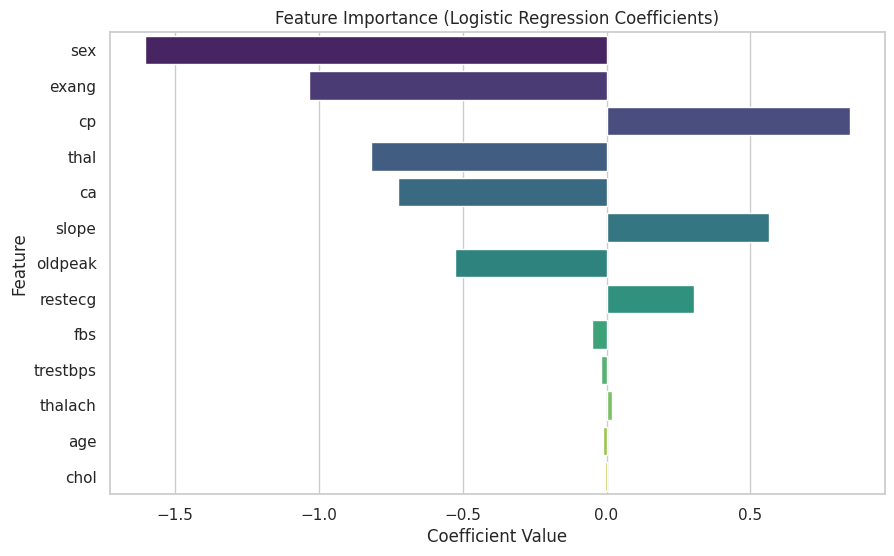

In [36]:
# Feature Importance using Logistic Regression Coefficients

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance,
    palette='viridis'
)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

Predict For New Patient

In [34]:
# Let's test the mode with a sample paitent

sample_data = np.array([
    52,   # age
    1,    # sex
    0,    # chest pain type
    125,  # resting BP
    212,  # cholesterol
    0,    # fasting blood sugar
    1,    # restecg
    168,  # max heart rate
    0,    # exercise induced angina
    1.0,  # oldpeak
    2,    # slope
    2,    # ca
    3     # thal
])

sample_data = sample_data.reshape(1,-1)

prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("❤️ The person is likely to have Heart Disease.")
else:
    print("💚 The person is NOT likely to have Heart Disease.")

💚 The person is NOT likely to have Heart Disease.


In [35]:
# Probability of Heart Disease
probability = model.predict_proba(sample_data)

print("Probability of No Heart Disease :", round(probability[0][0]*100,2),"%")
print("Probability of Heart Disease :", round(probability[0][1]*100,2),"%")

Probability of No Heart Disease : 77.33 %
Probability of Heart Disease : 22.67 %


MODEL PERFORMANCE

The Logistic Regression model achieved a training accuracy of **84.88%** and a testing accuracy of **81.46%**.

The small difference between training and testing accuracy indicates that the model generalizes well to unseen data and does not suffer from significant overfitting.

Therefore, the model can effectively predict whether a patient is likely to have heart disease based on the given medical attributes.

FINAL CONCLUSION
## Conclusion

A Logistic Regression model was successfully developed to predict heart disease using patient medical records.

The dataset was explored using Exploratory Data Analysis (EDA), and several visualizations were created to understand feature distributions and relationships. The dataset was then divided into training and testing sets, and the Logistic Regression model was trained.

The model achieved a training accuracy of **84.88%** and a testing accuracy of **81.46%**, demonstrating good predictive performance. Evaluation using the confusion matrix, classification report, and ROC curve showed that the model can classify patients with reasonable accuracy.

This project demonstrates the practical application of machine learning in healthcare and highlights how predictive analytics can assist in the early detection of heart disease.